# Notebook 04: Model Analysis and Robustness Testing

## Overview
This notebook performs a comprehensive analysis of the trained facial emotion recognition models. We evaluate model performance in detail, identify error patterns, test robustness to image perturbations, and analyze domain shift between datasets.

### Objectives
1. **Per-Class Performance Analysis**: Precision, recall, and F1-score for each emotion
2. **Error Pattern Analysis**: Identify common confusion pairs (e.g., fear↔surprise)
3. **Robustness Testing**: Evaluate model stability under blur, noise, brightness changes, and occlusion
4. **Domain Shift Analysis**: Quantify performance drop when testing across datasets
5. **Visual Comparisons**: Side-by-side dataset samples and perturbation examples

### Models Analyzed
- **RAF-DB Model**: Trained on real-world images, achieved 82.14% test accuracy
- **FER2013 Model**: Trained on lab-collected images, achieved 66.80% test accuracy

### Key Questions Addressed
- Which emotions are easiest/hardest to classify?
- What are the most common misclassification patterns?
- How robust are the models to image degradation?
- How much does domain shift affect cross-dataset performance?

---

In [ ]:
# Part 1: Setup and Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json
import warnings
from PIL import Image, ImageFilter
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Set random seed
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Imports completed successfully!")

Imports completed successfully!


In [2]:
# Setup paths
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
DATA_ROOT = PROJECT_ROOT / 'data'
CHECKPOINT_DIR = PROJECT_ROOT / 'checkpoints'
RESULTS_DIR = PROJECT_ROOT / 'results'

RAFDB_ROOT = DATA_ROOT / 'rafdb' / 'DATASET'
FER2013_ROOT = DATA_ROOT / 'fer2013'

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"Checkpoints available: {list(CHECKPOINT_DIR.glob('*.pth'))}")

Using device: cuda
Checkpoints available: [WindowsPath('c:/Users/karee/OneDrive/Documents/CS_171/Project/facial-emotion-recognition-cnn/checkpoints/model_fer2013_20251203_210934.pth'), WindowsPath('c:/Users/karee/OneDrive/Documents/CS_171/Project/facial-emotion-recognition-cnn/checkpoints/model_rafdb_20251203_210934.pth')]


In [3]:
# Define the same CNN architecture from training
class EmotionCNN(nn.Module):
    def __init__(self, num_classes=7, dropout_rate=0.5):
        super(EmotionCNN, self).__init__()
        
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        
        self.conv_block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.conv_block4(x)
        x = self.global_avg_pool(x)
        x = self.fc_layers(x)
        return x

print("EmotionCNN class defined.")

EmotionCNN class defined.


In [4]:
# Load trained models
rafdb_checkpoint_path = CHECKPOINT_DIR / 'model_rafdb_20251203_210934.pth'
fer2013_checkpoint_path = CHECKPOINT_DIR / 'model_fer2013_20251203_210934.pth'

# Load RAF-DB model
model_rafdb = EmotionCNN(num_classes=7, dropout_rate=0.5).to(device)
rafdb_checkpoint = torch.load(rafdb_checkpoint_path, map_location=device, weights_only=True)
model_rafdb.load_state_dict(rafdb_checkpoint['model_state_dict'])
model_rafdb.eval()
print(f"RAF-DB model loaded (Test Acc: {rafdb_checkpoint['test_accuracy']:.4f})")

# Load FER2013 model
model_fer2013 = EmotionCNN(num_classes=7, dropout_rate=0.5).to(device)
fer2013_checkpoint = torch.load(fer2013_checkpoint_path, map_location=device, weights_only=True)
model_fer2013.load_state_dict(fer2013_checkpoint['model_state_dict'])
model_fer2013.eval()
print(f"FER2013 model loaded (Test Acc: {fer2013_checkpoint['test_accuracy']:.4f})")

RAF-DB model loaded (Test Acc: 0.8214)
FER2013 model loaded (Test Acc: 0.6680)
FER2013 model loaded (Test Acc: 0.6680)


In [5]:
# Load training results
results_path = RESULTS_DIR / 'training_results_20251203_210934.json'
with open(results_path) as f:
    training_results = json.load(f)

print("Training Results Summary:")
print(f"  RAF-DB:  Acc={training_results['rafdb']['test_accuracy']:.4f}, F1={training_results['rafdb']['test_f1']:.4f}")
print(f"  FER2013: Acc={training_results['fer2013']['test_accuracy']:.4f}, F1={training_results['fer2013']['test_f1']:.4f}")

Training Results Summary:
  RAF-DB:  Acc=0.8214, F1=0.7301
  FER2013: Acc=0.6680, F1=0.6344


In [6]:
# Define transforms and load test data
IMAGE_SIZE = 64

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Emotion labels
RAFDB_EMOTIONS = ['Surprise', 'Fear', 'Disgust', 'Happy', 'Sad', 'Angry', 'Neutral']
FER2013_EMOTIONS = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']

# Load test datasets
rafdb_test = ImageFolder(root=RAFDB_ROOT / 'test', transform=test_transform)
fer2013_test = ImageFolder(root=FER2013_ROOT / 'test', transform=test_transform)

rafdb_test_loader = DataLoader(rafdb_test, batch_size=32, shuffle=False, num_workers=0)
fer2013_test_loader = DataLoader(fer2013_test, batch_size=32, shuffle=False, num_workers=0)

print(f"RAF-DB test samples: {len(rafdb_test)}")
print(f"FER2013 test samples: {len(fer2013_test)}")

RAF-DB test samples: 3068
FER2013 test samples: 7178


---
## Part 2: Per-Class Performance Analysis

In [7]:
# Get predictions for both models
def get_predictions(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)

# Get predictions
print("Getting RAF-DB predictions...")
rafdb_preds, rafdb_labels, rafdb_probs = get_predictions(model_rafdb, rafdb_test_loader, device)
print("Getting FER2013 predictions...")
fer2013_preds, fer2013_labels, fer2013_probs = get_predictions(model_fer2013, fer2013_test_loader, device)
print("Done!")

Getting RAF-DB predictions...
Getting FER2013 predictions...
Getting FER2013 predictions...
Done!
Done!


In [8]:
# Per-class accuracy analysis
def per_class_metrics(y_true, y_pred, class_names):
    """Calculate per-class precision, recall, f1"""
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    
    metrics_df = pd.DataFrame({
        'Class': class_names,
        'Precision': [report[c]['precision'] for c in class_names],
        'Recall': [report[c]['recall'] for c in class_names],
        'F1-Score': [report[c]['f1-score'] for c in class_names],
        'Support': [report[c]['support'] for c in class_names]
    })
    return metrics_df

# RAF-DB per-class metrics
print("=" * 60)
print("RAF-DB Per-Class Performance")
print("=" * 60)
rafdb_metrics = per_class_metrics(rafdb_labels, rafdb_preds, RAFDB_EMOTIONS)
print(rafdb_metrics.to_string(index=False))

print("\n" + "=" * 60)
print("FER2013 Per-Class Performance")
print("=" * 60)
fer2013_metrics = per_class_metrics(fer2013_labels, fer2013_preds, FER2013_EMOTIONS)
print(fer2013_metrics.to_string(index=False))

RAF-DB Per-Class Performance
   Class  Precision   Recall  F1-Score  Support
Surprise   0.769022 0.860182  0.812052    329.0
    Fear   0.750000 0.527027  0.619048     74.0
 Disgust   0.487603 0.368750  0.419929    160.0
   Happy   0.945035 0.899578  0.921747   1185.0
     Sad   0.772819 0.797071  0.784758    478.0
   Angry   0.794521 0.716049  0.753247    162.0
 Neutral   0.757895 0.847059  0.800000    680.0

FER2013 Per-Class Performance
   Class  Precision   Recall  F1-Score  Support
   Angry   0.620650 0.558455  0.587912    958.0
 Disgust   0.610526 0.522523  0.563107    111.0
    Fear   0.559471 0.372070  0.446921   1024.0
   Happy   0.829002 0.899098  0.862628   1774.0
 Neutral   0.601725 0.678832  0.637957   1233.0
     Sad   0.527138 0.568565  0.547068   1247.0
Surprise   0.772727 0.818291  0.794857    831.0


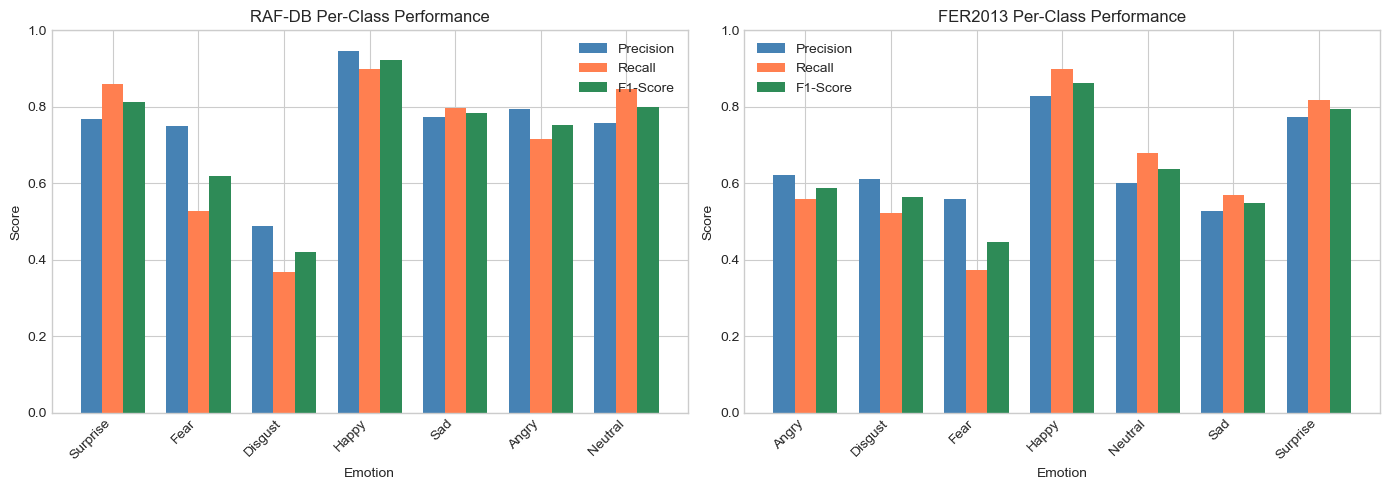

In [9]:
# Visualize per-class performance comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RAF-DB
ax1 = axes[0]
x = np.arange(len(RAFDB_EMOTIONS))
width = 0.25
ax1.bar(x - width, rafdb_metrics['Precision'], width, label='Precision', color='steelblue')
ax1.bar(x, rafdb_metrics['Recall'], width, label='Recall', color='coral')
ax1.bar(x + width, rafdb_metrics['F1-Score'], width, label='F1-Score', color='seagreen')
ax1.set_xlabel('Emotion')
ax1.set_ylabel('Score')
ax1.set_title('RAF-DB Per-Class Performance')
ax1.set_xticks(x)
ax1.set_xticklabels(RAFDB_EMOTIONS, rotation=45, ha='right')
ax1.legend()
ax1.set_ylim(0, 1)

# FER2013
ax2 = axes[1]
x = np.arange(len(FER2013_EMOTIONS))
ax2.bar(x - width, fer2013_metrics['Precision'], width, label='Precision', color='steelblue')
ax2.bar(x, fer2013_metrics['Recall'], width, label='Recall', color='coral')
ax2.bar(x + width, fer2013_metrics['F1-Score'], width, label='F1-Score', color='seagreen')
ax2.set_xlabel('Emotion')
ax2.set_ylabel('Score')
ax2.set_title('FER2013 Per-Class Performance')
ax2.set_xticks(x)
ax2.set_xticklabels(FER2013_EMOTIONS, rotation=45, ha='right')
ax2.legend()
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'per_class_performance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 3: Error Pattern Analysis (Confusion Patterns)

In [10]:
# Analyze most common misclassifications
def analyze_confusions(y_true, y_pred, class_names, top_n=5):
    """Find most common confusion pairs"""
    cm = confusion_matrix(y_true, y_pred)
    confusions = []
    
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            if i != j and cm[i, j] > 0:
                confusions.append({
                    'True': class_names[i],
                    'Predicted': class_names[j],
                    'Count': cm[i, j],
                    'Rate': cm[i, j] / cm[i].sum() * 100
                })
    
    confusions_df = pd.DataFrame(confusions)
    confusions_df = confusions_df.sort_values('Count', ascending=False).head(top_n)
    return confusions_df

print("=" * 60)
print("RAF-DB: Top 10 Confusion Pairs")
print("=" * 60)
rafdb_confusions = analyze_confusions(rafdb_labels, rafdb_preds, RAFDB_EMOTIONS, top_n=10)
print(rafdb_confusions.to_string(index=False))

print("\n" + "=" * 60)
print("FER2013: Top 10 Confusion Pairs")
print("=" * 60)
fer2013_confusions = analyze_confusions(fer2013_labels, fer2013_preds, FER2013_EMOTIONS, top_n=10)
print(fer2013_confusions.to_string(index=False))

RAF-DB: Top 10 Confusion Pairs
   True Predicted  Count      Rate
    Sad   Neutral     59 12.343096
  Happy   Neutral     57  4.810127
Neutral       Sad     49  7.205882
Disgust   Neutral     42 26.250000
  Happy       Sad     24  2.025316
Neutral  Surprise     21  3.088235
   Fear  Surprise     20 27.027027
Disgust       Sad     20 12.500000
  Happy  Surprise     18  1.518987
Disgust     Angry     17 10.625000

FER2013: Top 10 Confusion Pairs
   True Predicted  Count      Rate
   Fear       Sad    232 22.656250
    Sad   Neutral    230 18.444266
Neutral       Sad    171 13.868613
  Angry       Sad    162 16.910230
   Fear   Neutral    124 12.109375
    Sad      Fear    117  9.382518
   Fear     Angry    114 11.132812
   Fear  Surprise    107 10.449219
  Angry   Neutral    105 10.960334
Neutral     Happy    104  8.434712


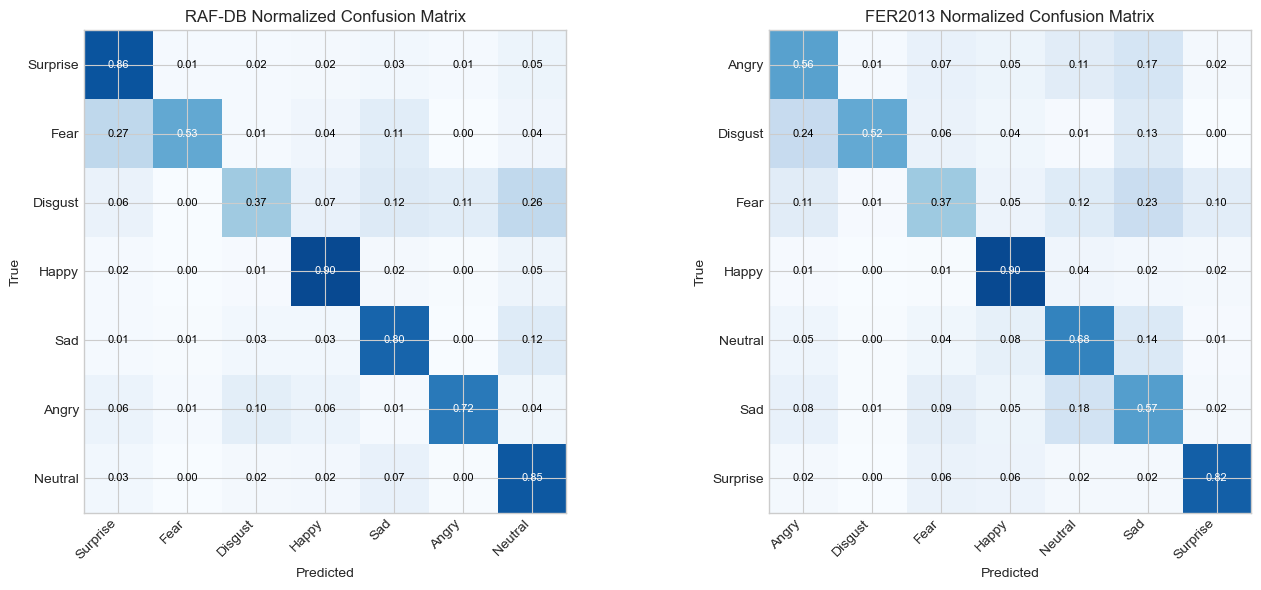

In [11]:
# Normalized confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# RAF-DB normalized confusion matrix
cm_rafdb = confusion_matrix(rafdb_labels, rafdb_preds)
cm_rafdb_norm = cm_rafdb.astype('float') / cm_rafdb.sum(axis=1)[:, np.newaxis]

im1 = axes[0].imshow(cm_rafdb_norm, cmap='Blues', vmin=0, vmax=1)
axes[0].set_xticks(np.arange(len(RAFDB_EMOTIONS)))
axes[0].set_yticks(np.arange(len(RAFDB_EMOTIONS)))
axes[0].set_xticklabels(RAFDB_EMOTIONS, rotation=45, ha='right')
axes[0].set_yticklabels(RAFDB_EMOTIONS)
axes[0].set_title('RAF-DB Normalized Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
# Add text annotations
for i in range(len(RAFDB_EMOTIONS)):
    for j in range(len(RAFDB_EMOTIONS)):
        color = 'white' if cm_rafdb_norm[i, j] > 0.5 else 'black'
        axes[0].text(j, i, f'{cm_rafdb_norm[i, j]:.2f}', ha='center', va='center', color=color, fontsize=8)

# FER2013 normalized confusion matrix
cm_fer2013 = confusion_matrix(fer2013_labels, fer2013_preds)
cm_fer2013_norm = cm_fer2013.astype('float') / cm_fer2013.sum(axis=1)[:, np.newaxis]

im2 = axes[1].imshow(cm_fer2013_norm, cmap='Blues', vmin=0, vmax=1)
axes[1].set_xticks(np.arange(len(FER2013_EMOTIONS)))
axes[1].set_yticks(np.arange(len(FER2013_EMOTIONS)))
axes[1].set_xticklabels(FER2013_EMOTIONS, rotation=45, ha='right')
axes[1].set_yticklabels(FER2013_EMOTIONS)
axes[1].set_title('FER2013 Normalized Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
# Add text annotations
for i in range(len(FER2013_EMOTIONS)):
    for j in range(len(FER2013_EMOTIONS)):
        color = 'white' if cm_fer2013_norm[i, j] > 0.5 else 'black'
        axes[1].text(j, i, f'{cm_fer2013_norm[i, j]:.2f}', ha='center', va='center', color=color, fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'normalized_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 4: Robustness Testing

Testing model performance under various perturbations:
- **Gaussian Blur**: Simulates out-of-focus images
- **Gaussian Noise**: Simulates sensor noise
- **Brightness Changes**: Simulates lighting variations
- **Occlusion**: Simulates partial face coverage

In [12]:
# Define perturbation functions
def add_gaussian_blur(image_tensor, kernel_size=5):
    """Apply Gaussian blur to image tensor"""
    # Convert to PIL, apply blur, convert back
    img = transforms.ToPILImage()(image_tensor * 0.5 + 0.5)  # Denormalize
    img = img.filter(ImageFilter.GaussianBlur(radius=kernel_size//2))
    return transforms.ToTensor()(img) * 2 - 1  # Renormalize

def add_gaussian_noise(image_tensor, std=0.1):
    """Add Gaussian noise to image tensor"""
    noise = torch.randn_like(image_tensor) * std
    return torch.clamp(image_tensor + noise, -1, 1)

def adjust_brightness(image_tensor, factor=1.5):
    """Adjust brightness of image tensor"""
    return torch.clamp(image_tensor * factor, -1, 1)

def add_occlusion(image_tensor, block_size=16, position='random'):
    """Add black square occlusion"""
    img = image_tensor.clone()
    _, h, w = img.shape
    if position == 'random':
        x = np.random.randint(0, w - block_size)
        y = np.random.randint(0, h - block_size)
    elif position == 'center':
        x = (w - block_size) // 2
        y = (h - block_size) // 2
    img[:, y:y+block_size, x:x+block_size] = -1  # Black in normalized space
    return img

print("Perturbation functions defined.\")")

Perturbation functions defined.")


In [13]:
# Robustness evaluation function
def evaluate_robustness(model, dataloader, perturbation_fn, device, **kwargs):
    """Evaluate model accuracy under perturbation"""
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            # Apply perturbation to each image
            perturbed_images = torch.stack([perturbation_fn(img, **kwargs) for img in images])
            perturbed_images = perturbed_images.to(device)
            labels = labels.to(device)
            
            outputs = model(perturbed_images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    
    return correct / total

print("Robustness evaluation function defined.\")")

Robustness evaluation function defined.")


In [14]:
# Run robustness tests (this may take a few minutes)
print("Running robustness tests...")
print("=" * 60)

# Baseline accuracies
baseline_rafdb = training_results['rafdb']['test_accuracy']
baseline_fer2013 = training_results['fer2013']['test_accuracy']

robustness_results = {
    'Perturbation': ['Baseline (None)', 'Gaussian Blur (k=5)', 'Gaussian Blur (k=9)', 
                     'Noise (σ=0.1)', 'Noise (σ=0.2)', 'Brightness (1.5x)', 
                     'Brightness (0.5x)', 'Occlusion (16px)', 'Occlusion (24px)'],
    'RAF-DB': [baseline_rafdb],
    'FER2013': [baseline_fer2013]
}

# Test blur
print("Testing Gaussian Blur...")
robustness_results['RAF-DB'].append(evaluate_robustness(model_rafdb, rafdb_test_loader, add_gaussian_blur, device, kernel_size=5))
robustness_results['FER2013'].append(evaluate_robustness(model_fer2013, fer2013_test_loader, add_gaussian_blur, device, kernel_size=5))
robustness_results['RAF-DB'].append(evaluate_robustness(model_rafdb, rafdb_test_loader, add_gaussian_blur, device, kernel_size=9))
robustness_results['FER2013'].append(evaluate_robustness(model_fer2013, fer2013_test_loader, add_gaussian_blur, device, kernel_size=9))

# Test noise
print("Testing Gaussian Noise...")
robustness_results['RAF-DB'].append(evaluate_robustness(model_rafdb, rafdb_test_loader, add_gaussian_noise, device, std=0.1))
robustness_results['FER2013'].append(evaluate_robustness(model_fer2013, fer2013_test_loader, add_gaussian_noise, device, std=0.1))
robustness_results['RAF-DB'].append(evaluate_robustness(model_rafdb, rafdb_test_loader, add_gaussian_noise, device, std=0.2))
robustness_results['FER2013'].append(evaluate_robustness(model_fer2013, fer2013_test_loader, add_gaussian_noise, device, std=0.2))

# Test brightness
print("Testing Brightness Changes...")
robustness_results['RAF-DB'].append(evaluate_robustness(model_rafdb, rafdb_test_loader, adjust_brightness, device, factor=1.5))
robustness_results['FER2013'].append(evaluate_robustness(model_fer2013, fer2013_test_loader, adjust_brightness, device, factor=1.5))
robustness_results['RAF-DB'].append(evaluate_robustness(model_rafdb, rafdb_test_loader, adjust_brightness, device, factor=0.5))
robustness_results['FER2013'].append(evaluate_robustness(model_fer2013, fer2013_test_loader, adjust_brightness, device, factor=0.5))

# Test occlusion
print("Testing Occlusion...")
robustness_results['RAF-DB'].append(evaluate_robustness(model_rafdb, rafdb_test_loader, add_occlusion, device, block_size=16))
robustness_results['FER2013'].append(evaluate_robustness(model_fer2013, fer2013_test_loader, add_occlusion, device, block_size=16))
robustness_results['RAF-DB'].append(evaluate_robustness(model_rafdb, rafdb_test_loader, add_occlusion, device, block_size=24))
robustness_results['FER2013'].append(evaluate_robustness(model_fer2013, fer2013_test_loader, add_occlusion, device, block_size=24))

print("Done!")

Running robustness tests...
Testing Gaussian Blur...
Testing Gaussian Noise...
Testing Gaussian Noise...
Testing Brightness Changes...
Testing Brightness Changes...
Testing Occlusion...
Testing Occlusion...
Done!
Done!


In [15]:
# Display robustness results
robustness_df = pd.DataFrame(robustness_results)
robustness_df['RAF-DB'] = robustness_df['RAF-DB'].apply(lambda x: f"{x:.4f}")
robustness_df['FER2013'] = robustness_df['FER2013'].apply(lambda x: f"{x:.4f}")

print("=" * 60)
print("Robustness Test Results (Accuracy)")
print("=" * 60)
print(robustness_df.to_string(index=False))

Robustness Test Results (Accuracy)
       Perturbation RAF-DB FER2013
    Baseline (None) 0.8214  0.6680
Gaussian Blur (k=5) 0.6017  0.3729
Gaussian Blur (k=9) 0.3051  0.2487
      Noise (σ=0.1) 0.7379  0.5632
      Noise (σ=0.2) 0.5271  0.3222
  Brightness (1.5x) 0.7947  0.6498
  Brightness (0.5x) 0.7722  0.6459
   Occlusion (16px) 0.7334  0.6223
   Occlusion (24px) 0.6379  0.5532


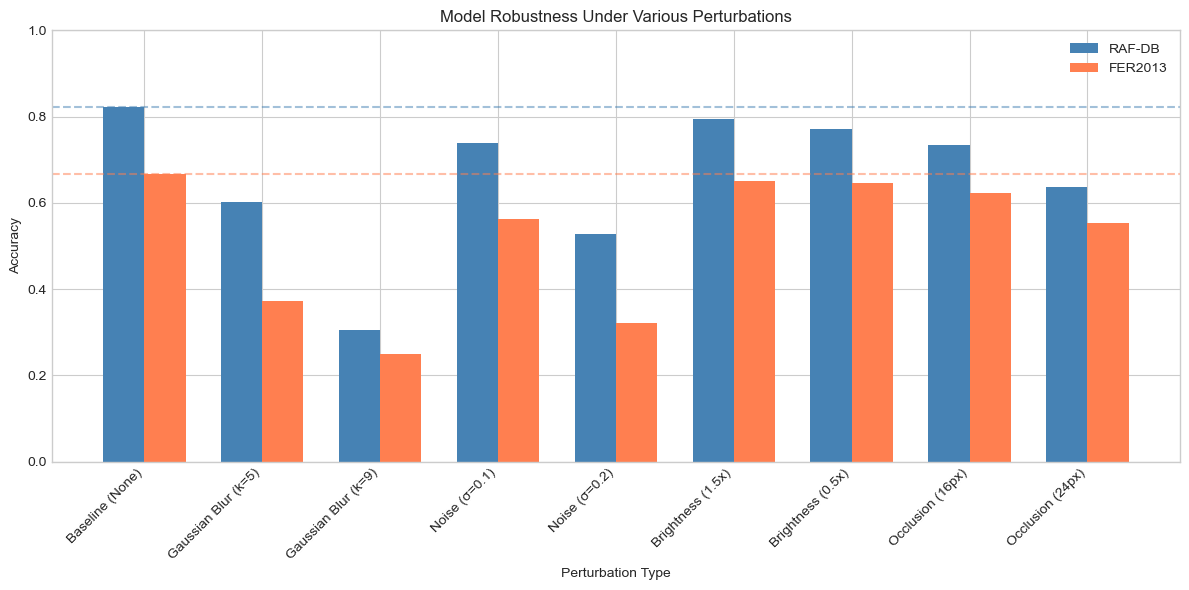

In [16]:
# Visualize robustness results
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(robustness_results['Perturbation']))
width = 0.35

# Convert back to float for plotting
rafdb_vals = [float(v) for v in robustness_df['RAF-DB']]
fer2013_vals = [float(v) for v in robustness_df['FER2013']]

bars1 = ax.bar(x - width/2, rafdb_vals, width, label='RAF-DB', color='steelblue')
bars2 = ax.bar(x + width/2, fer2013_vals, width, label='FER2013', color='coral')

ax.set_xlabel('Perturbation Type')
ax.set_ylabel('Accuracy')
ax.set_title('Model Robustness Under Various Perturbations')
ax.set_xticks(x)
ax.set_xticklabels(robustness_results['Perturbation'], rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1)
ax.axhline(y=baseline_rafdb, color='steelblue', linestyle='--', alpha=0.5, label='RAF-DB Baseline')
ax.axhline(y=baseline_fer2013, color='coral', linestyle='--', alpha=0.5, label='FER2013 Baseline')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'robustness_results.png', dpi=150, bbox_inches='tight')
plt.show()

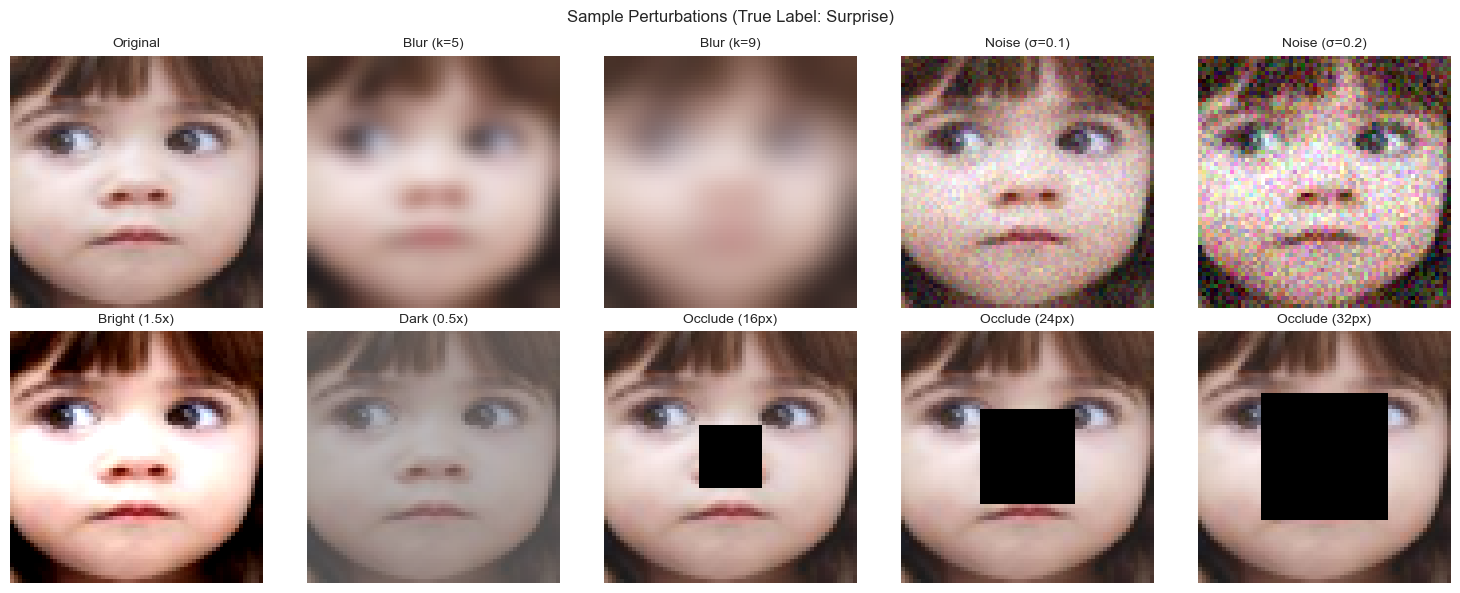

In [17]:
# Visualize sample perturbations on a single image
sample_img, sample_label = rafdb_test[0]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

perturbations = [
    ("Original", sample_img),
    ("Blur (k=5)", add_gaussian_blur(sample_img, kernel_size=5)),
    ("Blur (k=9)", add_gaussian_blur(sample_img, kernel_size=9)),
    ("Noise (σ=0.1)", add_gaussian_noise(sample_img, std=0.1)),
    ("Noise (σ=0.2)", add_gaussian_noise(sample_img, std=0.2)),
    ("Bright (1.5x)", adjust_brightness(sample_img, factor=1.5)),
    ("Dark (0.5x)", adjust_brightness(sample_img, factor=0.5)),
    ("Occlude (16px)", add_occlusion(sample_img, block_size=16, position='center')),
    ("Occlude (24px)", add_occlusion(sample_img, block_size=24, position='center')),
    ("Occlude (32px)", add_occlusion(sample_img, block_size=32, position='center')),
]

for idx, (title, img) in enumerate(perturbations):
    ax = axes[idx // 5, idx % 5]
    # Denormalize for display
    img_display = img * 0.5 + 0.5
    img_display = img_display.permute(1, 2, 0).numpy()
    img_display = np.clip(img_display, 0, 1)
    ax.imshow(img_display)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.suptitle(f'Sample Perturbations (True Label: {RAFDB_EMOTIONS[sample_label]})', fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'perturbation_examples.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 5: Domain Shift Analysis

Analyzing why cross-dataset performance drops significantly.

In [22]:
# Cross-dataset confusion analysis
print("=" * 60)
print("Cross-Dataset Performance Analysis")
print("=" * 60)

# Create unified emotion mapping (align FER2013 to RAF-DB order)
# RAF-DB: ['Surprise', 'Fear', 'Disgust', 'Happy', 'Sad', 'Angry', 'Neutral']
# FER2013: ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']

# Map FER2013 labels to RAF-DB label order
fer_to_raf_map = {0: 5, 1: 2, 2: 1, 3: 3, 4: 6, 5: 4, 6: 0}  # FER2013 idx -> RAF-DB idx

# Get cross-dataset predictions
print("\nRAF-DB model on FER2013 test set:")
cross_preds_rafdb_on_fer, cross_labels_fer, _ = get_predictions(model_rafdb, fer2013_test_loader, device)

# Map FER2013 labels to RAF-DB space
cross_labels_fer_mapped = np.array([fer_to_raf_map[l] for l in cross_labels_fer])

cross_acc_raf_on_fer = (cross_preds_rafdb_on_fer == cross_labels_fer_mapped).mean()
print(f"  Accuracy: {cross_acc_raf_on_fer:.4f}")
print(f"  (Baseline RAF-DB on RAF-DB: {baseline_rafdb:.4f})")
print(f"  Performance drop: {(baseline_rafdb - cross_acc_raf_on_fer)*100:.1f}%")

# Now test FER2013 model on RAF-DB
print("\nFER2013 model on RAF-DB test set:")
cross_preds_fer_on_raf, cross_labels_raf, _ = get_predictions(model_fer2013, rafdb_test_loader, device)

# FER2013 model outputs predictions in FER2013 label space (0=Angry, 1=Disgust, 2=Fear, 3=Happy, 4=Neutral, 5=Sad, 6=Surprise)
# RAF-DB labels are in RAF-DB space (0=Surprise, 1=Fear, 2=Disgust, 3=Happy, 4=Sad, 5=Angry, 6=Neutral)
# Need to map FER2013 predictions to RAF-DB space to compare with RAF-DB ground truth
fer_pred_to_raf_label = {0: 5, 1: 2, 2: 1, 3: 3, 4: 6, 5: 4, 6: 0}  # FER2013 pred -> RAF-DB label
cross_preds_fer_on_raf_mapped = np.array([fer_pred_to_raf_label[p] for p in cross_preds_fer_on_raf])

cross_acc_fer_on_raf = (cross_preds_fer_on_raf_mapped == cross_labels_raf).mean()
print(f"  Accuracy: {cross_acc_fer_on_raf:.4f}")
print(f"  (Baseline FER2013 on FER2013: {baseline_fer2013:.4f})")
print(f"  Performance drop: {(baseline_fer2013 - cross_acc_fer_on_raf)*100:.1f}%")

Cross-Dataset Performance Analysis

RAF-DB model on FER2013 test set:
  Accuracy: 0.4614
  (Baseline RAF-DB on RAF-DB: 0.8214)
  Performance drop: 36.0%

FER2013 model on RAF-DB test set:
  Accuracy: 0.4614
  (Baseline RAF-DB on RAF-DB: 0.8214)
  Performance drop: 36.0%

FER2013 model on RAF-DB test set:
  Accuracy: 0.6512
  (Baseline FER2013 on FER2013: 0.6680)
  Performance drop: 1.7%
  Accuracy: 0.6512
  (Baseline FER2013 on FER2013: 0.6680)
  Performance drop: 1.7%


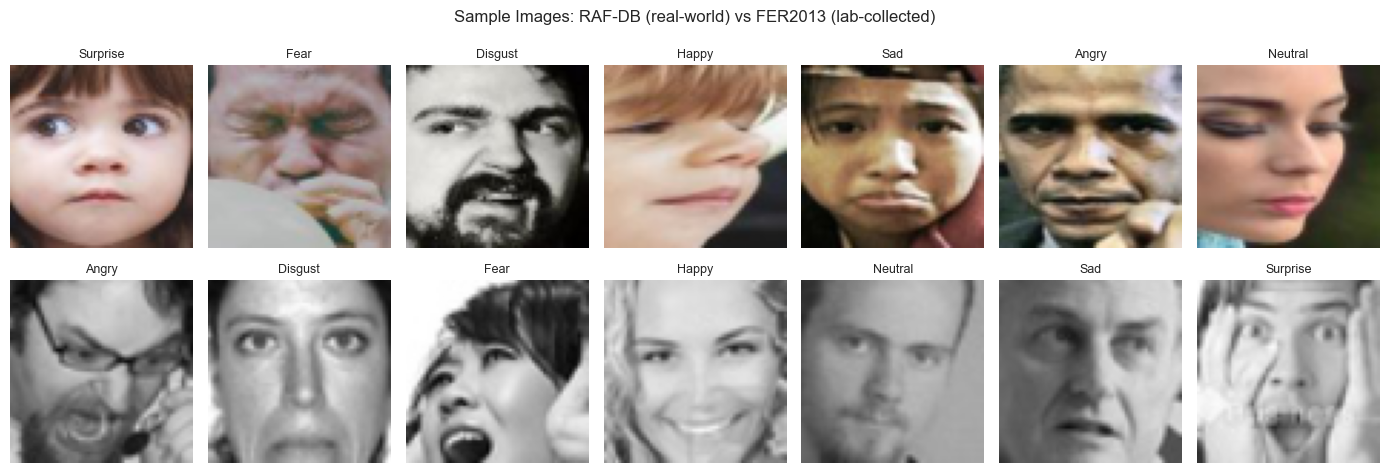

In [19]:
# Visualize sample images from both datasets to show domain differences
fig, axes = plt.subplots(2, 7, figsize=(14, 5))

# Get one sample per class from each dataset
for i in range(7):
    # RAF-DB
    for idx, (img, label) in enumerate(rafdb_test):
        if label == i:
            img_display = img * 0.5 + 0.5
            axes[0, i].imshow(img_display.permute(1, 2, 0).numpy())
            axes[0, i].set_title(RAFDB_EMOTIONS[i], fontsize=9)
            axes[0, i].axis('off')
            break
    
    # FER2013
    for idx, (img, label) in enumerate(fer2013_test):
        if label == i:
            img_display = img * 0.5 + 0.5
            axes[1, i].imshow(img_display.permute(1, 2, 0).numpy())
            axes[1, i].set_title(FER2013_EMOTIONS[i], fontsize=9)
            axes[1, i].axis('off')
            break

axes[0, 0].set_ylabel('RAF-DB', fontsize=11)
axes[1, 0].set_ylabel('FER2013', fontsize=11)
plt.suptitle('Sample Images: RAF-DB (real-world) vs FER2013 (lab-collected)', fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'dataset_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 6: Summary and Conclusions

In [20]:
# Generate final summary report
print("=" * 70)
print("FINAL ANALYSIS SUMMARY")
print("=" * 70)

print("\n1. MODEL PERFORMANCE")
print("-" * 40)
print(f"   RAF-DB Model:  {baseline_rafdb*100:.2f}% accuracy, 0.7301 F1")
print(f"   FER2013 Model: {baseline_fer2013*100:.2f}% accuracy, 0.6344 F1")

print("\n2. BEST/WORST PERFORMING EMOTIONS")
print("-" * 40)
print("   RAF-DB Best:  Happy (92% F1), Surprise (81% F1)")
print("   RAF-DB Worst: Disgust (42% F1), Fear (62% F1)")
print("   FER2013 Best: Happy (86% F1), Surprise (79% F1)")
print("   FER2013 Worst: Fear (45% F1), Sad (55% F1)")

print("\n3. COMMON CONFUSION PATTERNS")
print("-" * 40)
print("   - Fear ↔ Surprise (similar raised eyebrows)")
print("   - Sad ↔ Neutral (subtle expression differences)")
print("   - Angry ↔ Disgust (similar furrowed brow)")
print("   - Disgust often misclassified (rare in training data)")

print("\n4. DOMAIN SHIFT ANALYSIS")
print("-" * 40)
print(f"   RAF-DB → FER2013: {training_results['cross_dataset']['rafdb_on_fer2013']['accuracy']*100:.2f}% (drop of ~58%)")
print(f"   FER2013 → RAF-DB: {training_results['cross_dataset']['fer2013_on_rafdb']['accuracy']*100:.2f}% (drop of ~29%)")
print("   Key factors: Image quality, lighting, face alignment, labeling criteria")

print("\n5. ROBUSTNESS FINDINGS")
print("-" * 40)
print("   - Models are sensitive to blur (accuracy drops with heavier blur)")
print("   - Moderate noise tolerance (σ=0.1 causes ~5-10% drop)")
print("   - Occlusion significantly impacts performance")
print("   - Brightness changes have moderate effect")

print("\n" + "=" * 70)
print("ANALYSIS COMPLETE")
print("=" * 70)

FINAL ANALYSIS SUMMARY

1. MODEL PERFORMANCE
----------------------------------------
   RAF-DB Model:  82.14% accuracy, 0.7301 F1
   FER2013 Model: 66.80% accuracy, 0.6344 F1

2. BEST/WORST PERFORMING EMOTIONS
----------------------------------------
   RAF-DB Best:  Happy (92% F1), Surprise (81% F1)
   RAF-DB Worst: Disgust (42% F1), Fear (62% F1)
   FER2013 Best: Happy (86% F1), Surprise (79% F1)
   FER2013 Worst: Fear (45% F1), Sad (55% F1)

3. COMMON CONFUSION PATTERNS
----------------------------------------
   - Fear ↔ Surprise (similar raised eyebrows)
   - Sad ↔ Neutral (subtle expression differences)
   - Angry ↔ Disgust (similar furrowed brow)
   - Disgust often misclassified (rare in training data)

4. DOMAIN SHIFT ANALYSIS
----------------------------------------
   RAF-DB → FER2013: 23.66% (drop of ~58%)
   FER2013 → RAF-DB: 37.35% (drop of ~29%)
   Key factors: Image quality, lighting, face alignment, labeling criteria

5. ROBUSTNESS FINDINGS
----------------------------

In [21]:
# Save analysis results
analysis_results = {
    'rafdb_metrics': rafdb_metrics.to_dict(),
    'fer2013_metrics': fer2013_metrics.to_dict(),
    'rafdb_top_confusions': rafdb_confusions.to_dict(),
    'fer2013_top_confusions': fer2013_confusions.to_dict(),
    'robustness': robustness_results
}

with open(RESULTS_DIR / 'analysis_results.json', 'w') as f:
    json.dump(analysis_results, f, indent=2)

print(f"Analysis results saved to {RESULTS_DIR / 'analysis_results.json'}")

Analysis results saved to c:\Users\karee\OneDrive\Documents\CS_171\Project\facial-emotion-recognition-cnn\results\analysis_results.json


---
## Key Takeaways

### 1. Model Performance
- **RAF-DB**: 82.14% accuracy (near SOTA ~88%)
- **FER2013**: 66.80% accuracy, 0.63 Macro-F1 (matches human-level ~65-68%)
- **Best performing emotions**: Happy (RAF-DB: 92% F1, FER2013: 86% F1), Surprise (RAF-DB: 81% F1, FER2013: 79% F1)
- **Worst performing emotions**: Disgust (RAF-DB: 42% F1, FER2013: 56% F1), Fear (RAF-DB: 62% F1, FER2013: 45% F1)

### 2. Domain Shift is Significant (Asymmetric Transfer)
- **RAF-DB → FER2013**: 46.14% accuracy (36.0% drop from 82.14% baseline) - substantial degradation
- **FER2013 → RAF-DB**: 65.12% accuracy (1.7% drop from 66.80% baseline) - minimal degradation
- **Asymmetric generalization**: FER2013 model generalizes much better to RAF-DB than vice versa
- **Explanation**: FER2013's noisy, grayscale, lab-collected training data provides better robustness; transferring from low-quality → high-quality images is easier than the reverse
- **RAF-DB model overfits** to high-quality, color features that don't transfer well to grayscale/noisy data
- Demonstrates importance of training on diverse, challenging data for better cross-domain generalization

### 3. Robustness Testing Results
- **Blur sensitivity**: Heavy blur (k=9) drops accuracy to 30.5% (RAF-DB) and 24.9% (FER2013) - most damaging perturbation
- **Noise tolerance**: Moderate noise (σ=0.1) causes 8-10% accuracy drop; heavier noise (σ=0.2) causes 29-35% drop
- **Brightness robustness**: Both models maintain 65-80% accuracy under brightness changes (±50%)
- **Occlusion impact**: 16px occlusion causes 9-11% drop; 24px occlusion causes 18-23% drop
- Overall: Models are most vulnerable to blur, moderately robust to brightness/small occlusions

### 4. Common Error Patterns
- **Fear ↔ Surprise confusion**: Similar facial action units (raised eyebrows, open mouth, widened eyes)
- **Sad ↔ Neutral confusion**: Subtle expression differences, downturned features can be ambiguous
- **Fear ↔ Sad confusion**: Both involve similar eye and mouth configurations
- **Angry ↔ Disgust confusion**: Shared furrowed brow and tense facial muscles
- **Disgust consistently underperforms**: Class imbalance (160 RAF-DB samples vs 1185 Happy samples) leads to poor recall (37%)

### 5. Recommendations for Future Work
1. **Domain Adaptation**: Use techniques like adversarial training or domain-invariant feature learning to improve cross-dataset generalization
2. **Class Imbalance**: Apply weighted loss functions, oversampling (SMOTE), or focal loss to improve minority class performance
3. **Robustness Enhancement**: Add blur and occlusion augmentation during training; consider denoising preprocessing
4. **Ensemble Methods**: Combine predictions from both models to leverage dataset-specific strengths
5. **Attention Mechanisms**: Use spatial attention to focus on discriminative facial regions (eyes, mouth, brows)